In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch import nn, optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed để kết quả có thể reproduce
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.10.0+cpu
Device: cpu


In [22]:
# Load dữ liệu
df = pd.read_csv('./data/auto-mpg.csv')

print("Shape của dataset:", df.shape)
print("\n5 dòng đầu tiên:")
print(df.head())

print("\nThông tin về các cột:")
print(df.info())

print("\nThống kê mô tả:")
print(df.describe())

Shape của dataset: (398, 9)

5 dòng đầu tiên:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Thông tin về các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           3

In [23]:
# Kiểm tra missing values
print("Missing values trong mỗi cột:")
print(df.isnull().sum())

# Kiểm tra các giá trị '?' (thường được dùng để đánh dấu missing trong dataset này)
print("\nKiểm tra giá trị '?' trong horsepower:")
print(df[df['horsepower'] == '?'].shape[0], "dòng chứa '?'")

Missing values trong mỗi cột:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Kiểm tra giá trị '?' trong horsepower:
6 dòng chứa '?'


In [24]:
# Xử lý dữ liệu
# 1. Loại bỏ cột 'car name' vì không cần thiết cho prediction
df = df.drop('car name', axis=1)

# 2. Xử lý giá trị '?' trong cột horsepower
# Chuyển '?' thành NaN, sau đó replace bằng median
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

print("Dữ liệu sau khi xử lý:")
print(df.info())
print("\nKhông còn missing values:", df.isnull().sum().sum())

Dữ liệu sau khi xử lý:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB
None

Không còn missing values: 0


C:\Users\khacb\AppData\Local\Temp\ipykernel_28204\4251454514.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


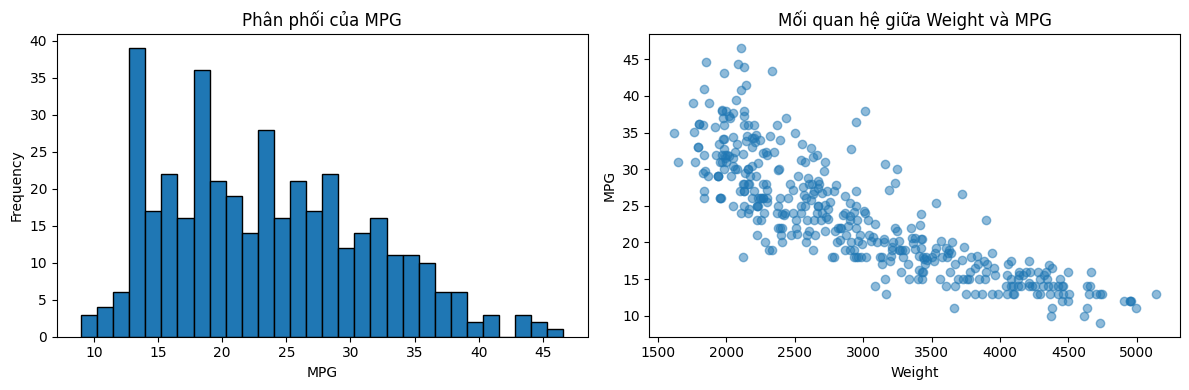

In [25]:
# Visualize phân phối của target (mpg)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['mpg'], bins=30, edgecolor='black')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.title('Phân phối của MPG')

plt.subplot(1, 2, 2)
plt.scatter(df['weight'], df['mpg'], alpha=0.5)
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Mối quan hệ giữa Weight và MPG')

plt.tight_layout()
plt.show()

In [26]:
# Tách features (X) và target (y)
# X: tất cả các cột trừ mpg
# y: cột mpg
X = df.drop('mpg', axis=1).values
y = df['mpg'].values.reshape(-1, 1)  # Reshape để có shape (n_samples, 1)

print("Shape của X:", X.shape)  # (n_samples, n_features)
print("Shape của y:", y.shape)  # (n_samples, 1)

# Split train/test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Shape của X: (398, 7)
Shape của y: (398, 1)

Train set: 318 samples
Test set: 80 samples


In [27]:
# Chuẩn hóa dữ liệu (Normalization)
# Quan trọng: Chỉ fit scaler trên train set, sau đó transform cả train và test
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

print("Dữ liệu đã được chuẩn hóa (mean=0, std=1)")
print(f"X_train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")
print(f"y_train mean: {y_train.mean():.4f}, std: {y_train.std():.4f}")

Dữ liệu đã được chuẩn hóa (mean=0, std=1)
X_train mean: 0.0000, std: 1.0000
y_train mean: -0.0000, std: 1.0000


In [28]:
# Chuyển đổi sang PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print("PyTorch tensors:")
print(f"X_train: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"y_train: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")

PyTorch tensors:
X_train: torch.Size([318, 7]), dtype: torch.float32
y_train: torch.Size([318, 1]), dtype: torch.float32


In [29]:
# Tạo DataLoader để training theo batch
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 10
Test batches: 3


In [30]:
class MLPRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=1):
        """
        MLP cho bài toán Regression
        
        Args:
            input_size: Số lượng features đầu vào
            hidden_sizes: List chứa số neurons trong mỗi hidden layer
            output_size: Số lượng outputs (1 cho regression)
        """
        super(MLPRegressor, self).__init__()
        
        # Tạo list các layers
        layers = []
        
        # Input layer -> First hidden layer
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.2))  # Dropout để tránh overfitting
        
        # Hidden layers
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
        
        # Output layer (không có activation vì là regression)
        layers.append(nn.Linear(hidden_sizes[-1], output_size))
        
        # Kết hợp tất cả layers thành Sequential
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Tạo model
input_size = X_train.shape[1]  # 7 features
hidden_sizes = [64, 32, 16]  # 3 hidden layers
model = MLPRegressor(input_size, hidden_sizes)

print("Model Architecture:")
print(model)
print(f"\nTổng số parameters: {sum(p.numel() for p in model.parameters())}")

Model Architecture:
MLPRegressor(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

Tổng số parameters: 3137


In [31]:
# Loss function: MSE cho regression
criterion = nn.MSELoss()

# Optimizer: Adam
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam với learning rate = {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam với learning rate = 0.001


## Bước 6: Training Model

In [32]:
def train_epoch(model, train_loader, criterion, optimizer):
    """
    Training cho 1 epoch
    """
    model.train()  # Set model to training mode
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Tính gradients
        optimizer.step()  # Update weights
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss

def evaluate(model, test_loader, criterion):
    """
    Đánh giá model trên test set
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    
    with torch.no_grad():  # Không tính gradients khi evaluate
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            total_loss += loss.item()
    
    avg_loss = total_loss / len(test_loader)
    return avg_loss

print("Hàm training và evaluation đã được định nghĩa!")

Hàm training và evaluation đã được định nghĩa!


In [33]:
# Training loop
num_epochs = 200
train_losses = []
test_losses = []

print("Bắt đầu training...\n")

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    
    # Evaluation
    test_loss = evaluate(model, test_loader, criterion)
    test_losses.append(test_loss)
    
    # In ra kết quả mỗi 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f} - "
              f"Test Loss: {test_loss:.4f}")

print("\nTraining hoàn thành!")

Bắt đầu training...

Epoch [20/200] - Train Loss: 0.1860 - Test Loss: 0.0911
Epoch [40/200] - Train Loss: 0.1773 - Test Loss: 0.0865
Epoch [60/200] - Train Loss: 0.1841 - Test Loss: 0.0834
Epoch [80/200] - Train Loss: 0.1567 - Test Loss: 0.0791
Epoch [100/200] - Train Loss: 0.1448 - Test Loss: 0.0779
Epoch [120/200] - Train Loss: 0.1488 - Test Loss: 0.0749
Epoch [140/200] - Train Loss: 0.1465 - Test Loss: 0.0690
Epoch [160/200] - Train Loss: 0.1417 - Test Loss: 0.0715
Epoch [180/200] - Train Loss: 0.1160 - Test Loss: 0.0761
Epoch [200/200] - Train Loss: 0.1182 - Test Loss: 0.0762

Training hoàn thành!


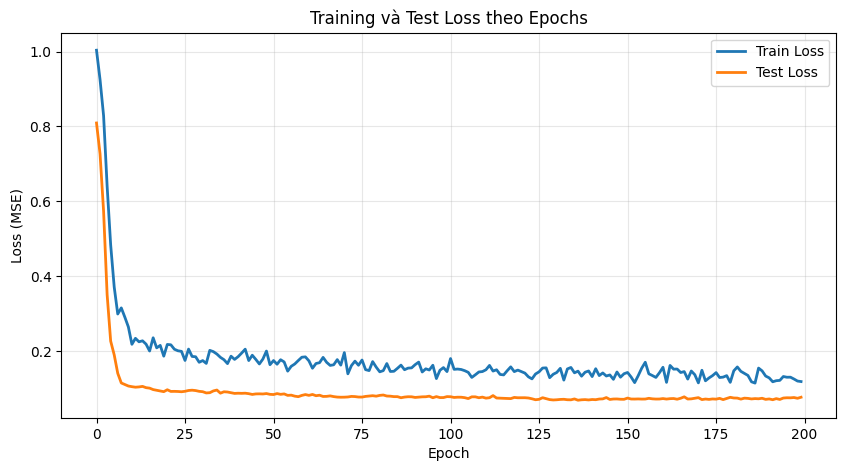

Final Train Loss: 0.1182
Final Test Loss: 0.0762


In [34]:
# Plot training và test loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training và Test Loss theo Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [35]:
# Dự đoán trên toàn bộ test set
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

# Inverse transform để có được giá trị MPG thực tế
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# Tính các metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("="*50)
print("KẾT QUẢ ĐÁNH GIÁ MODEL")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("="*50)
print("\nGiải thích:")
print(f"- Trung bình model dự đoán sai khoảng {mae:.2f} MPG")
print(f"- Model giải thích được {r2*100:.2f}% sự biến thiên của MPG")

KẾT QUẢ ĐÁNH GIÁ MODEL
Mean Squared Error (MSE): 5.3132
Root Mean Squared Error (RMSE): 2.3050
Mean Absolute Error (MAE): 1.7292
R² Score: 0.9012

Giải thích:
- Trung bình model dự đoán sai khoảng 1.73 MPG
- Model giải thích được 90.12% sự biến thiên của MPG


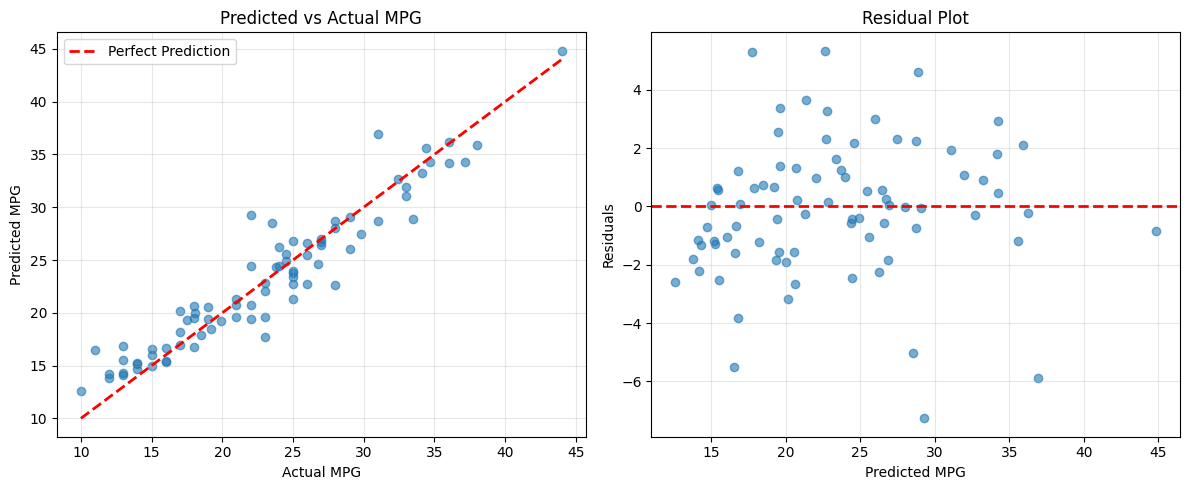

In [36]:
# Visualize predictions vs actual values
plt.figure(figsize=(12, 5))

# Scatter plot: Predicted vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test_original, y_pred, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Predicted vs Actual MPG')
plt.legend()
plt.grid(True, alpha=0.3)

# Residuals plot
plt.subplot(1, 2, 2)
residuals = y_test_original - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()